In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("raw_sales.csv")
df.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datesold      29580 non-null  object
 1   postcode      29580 non-null  int64 
 2   price         29580 non-null  int64 
 3   propertyType  29580 non-null  object
 4   bedrooms      29580 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [4]:
df['datesold'] = pd.to_datetime(df['datesold'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datesold      29580 non-null  datetime64[ns]
 1   postcode      29580 non-null  int64         
 2   price         29580 non-null  int64         
 3   propertyType  29580 non-null  object        
 4   bedrooms      29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


In [5]:
df.isna().sum()

datesold        0
postcode        0
price           0
propertyType    0
bedrooms        0
dtype: int64

In [6]:
df.duplicated().sum()


0

In [7]:
df.describe()


,postcode,price,bedrooms
count,29580.000000,2.958000e+04,29580.000000
mean,2730.249730,6.097363e+05,3.250169
std,146.717292,2.817079e+05,0.951275
min,2600.000000,5.650000e+04,0.000000
25%,2607.000000,4.400000e+05,3.000000
50%,2615.000000,5.500000e+05,3.000000
75%,2905.000000,7.050000e+05,4.000000
max,2914.000000,8.000000e+06,5.000000


In [8]:
df = df[df['propertyType'] == 'house']

In [9]:
df = df.rename(columns={
    'propertyType': 'unique_id',
    'datesold': 'ds',
    'price': 'y'
})

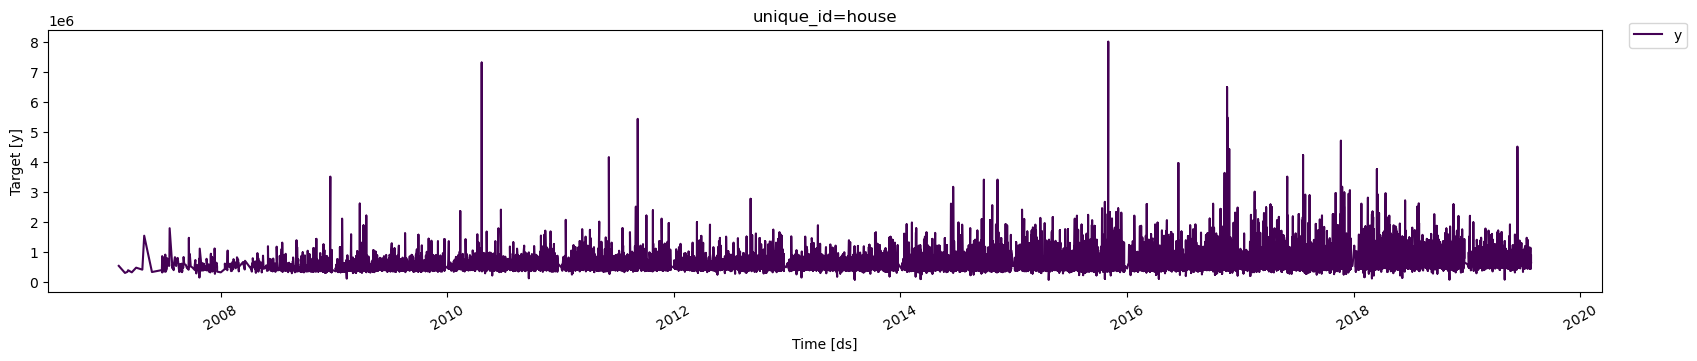

In [10]:
plot_series(df=df, ids=["house"], palette="viridis")

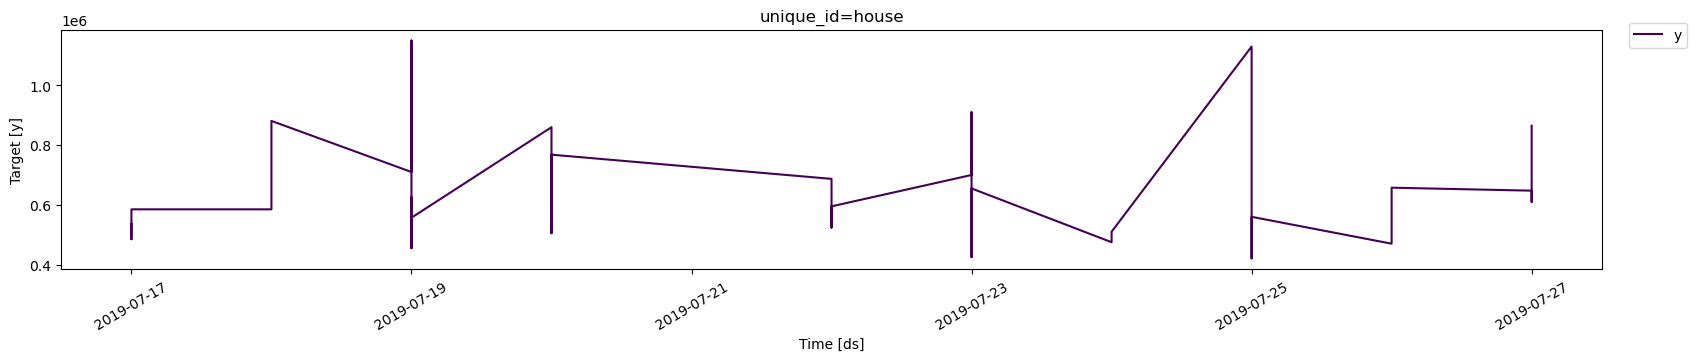

In [11]:
plot_series(df=df, ids=["house"], max_insample_length=56,palette="viridis")

In [12]:
df1=df[['unique_id', 'ds','y']]

In [13]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [14]:
horizon = 7

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=7),
    SeasonalNaive(season_length=7)
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=df1)
preds = sf.predict(h=horizon)

In [15]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,house,2019-07-28,865000.0,647956.125,631428.5625,560000.0
1,house,2019-07-29,865000.0,647956.125,631428.5625,470000.0
2,house,2019-07-30,865000.0,647956.125,631428.5625,610000.0
3,house,2019-07-31,865000.0,647956.125,631428.5625,657500.0
4,house,2019-08-01,865000.0,647956.125,631428.5625,647500.0


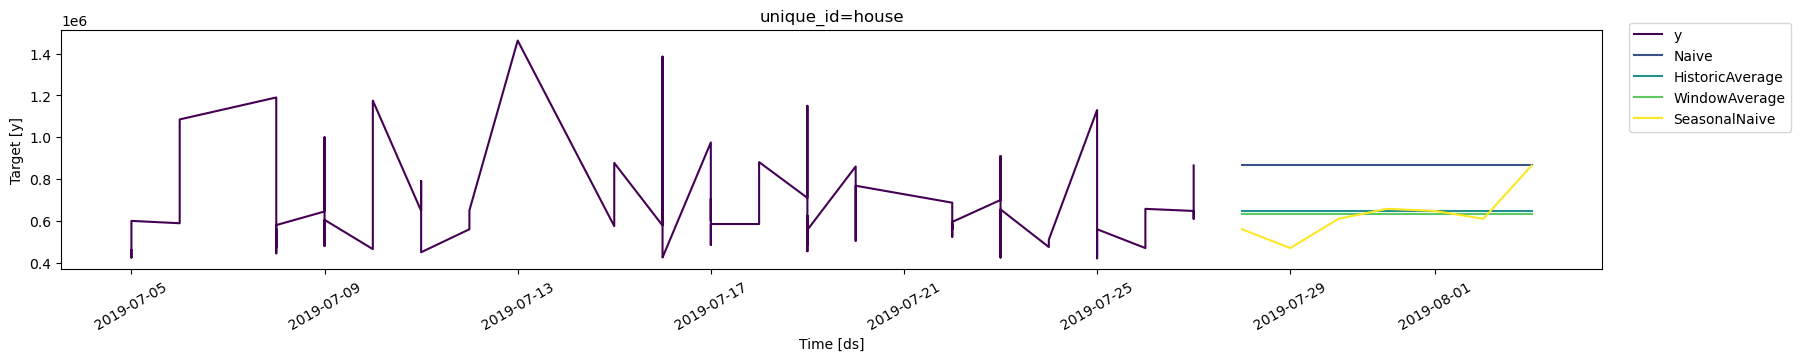

In [16]:
plot_series(
    df=df1, 
    forecasts_df=preds, 
    ids=["house"], 
    max_insample_length=114, 
    palette="viridis")

In [17]:
unique_ids = ["house"]
small_df = df1[df1["unique_id"].isin(unique_ids)]
test = small_df.groupby("unique_id").tail(8874)
train = small_df.drop(test.index).reset_index(drop=True)

In [18]:
sf.fit(df=train)

preds = sf.predict(h=horizon)

eval_df1 = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [19]:
evaluation = evaluate(
    eval_df1,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,house,mae,186900.0,186071.428571,187836.732143,183128.571429


In [20]:
evaluation = evaluation.drop(['unique_id'], axis=1).reset_index()
evaluation

,index,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,0,mae,186900.0,186071.428571,187836.732143,183128.571429


In [21]:
evaluation_df=evaluation[['metric','Naive', 'HistoricAverage','WindowAverage','SeasonalNaive']]

In [22]:
evaluation_df = pd.melt(
    evaluation_df,
    id_vars=['metric'],
    var_name='method',
    value_name='value'
)
print(evaluation_df)

  metric           method          value
0    mae            Naive  186900.000000
1    mae  HistoricAverage  186071.428571
2    mae    WindowAverage  187836.732143
3    mae    SeasonalNaive  183128.571429


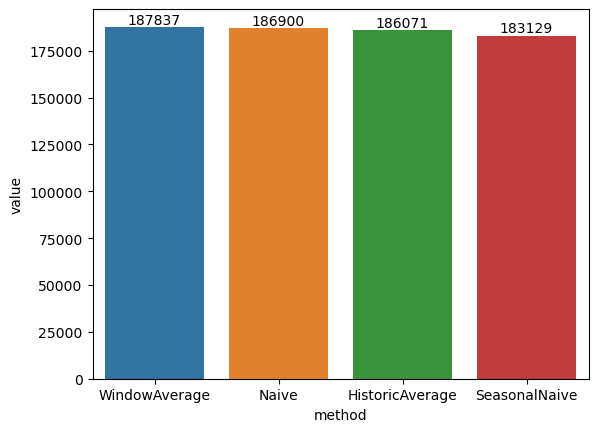

In [23]:
ax=sns.barplot(x='method', y='value', data=evaluation_df.sort_values(by='value', ascending=False))
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [24]:
from statsforecast.models import AutoARIMA

In [25]:
unique_ids = ["house"]

small_train = train[train["unique_id"].isin(unique_ids)]
small_test = test[test["unique_id"].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="D", n_jobs=-1)
sf.fit(df=small_train)
arima_preds = sf.predict(h=horizon)

arima_eval_df = pd.merge(arima_preds, eval_df1, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae],
)
arima_eval

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,house,mae,187343.413393,187002.022321,186900.0,186071.428571,187836.732143,183128.571429


In [26]:
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,187343.413393,187002.022321,186900.0,186071.428571,187836.732143,183128.571429


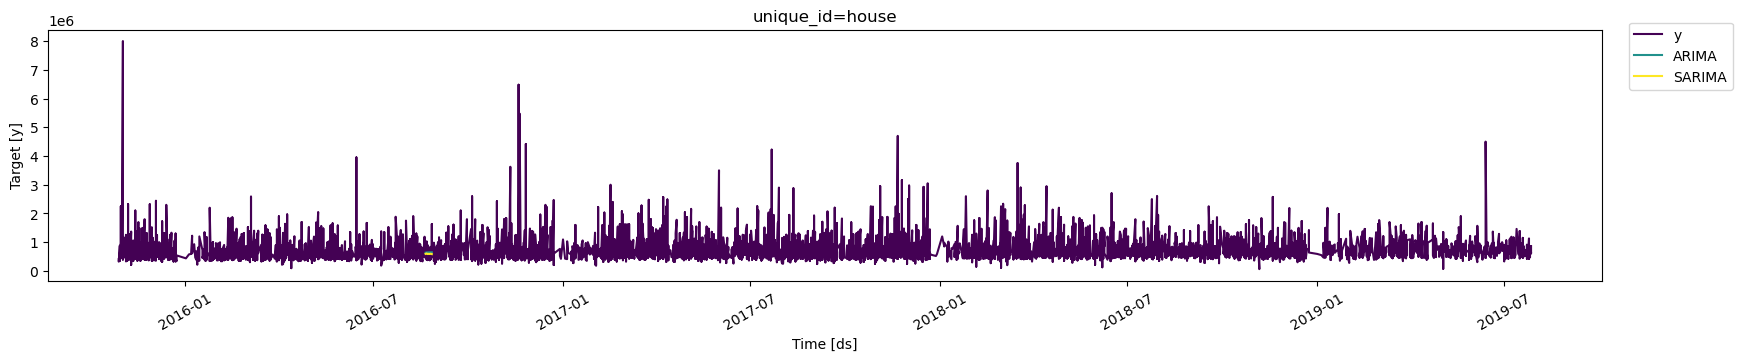

In [27]:
plot_series(
    df=df1, 
    forecasts_df=arima_preds, 
    ids=["house"], 
    max_insample_length=11400, 
    palette="viridis")

In [28]:
evaluation_df1 = pd.melt(
    arima_eval,
    id_vars=['metric'],
    var_name='method',
    value_name='value'
)
print(evaluation_df1)

  metric           method          value
0    mae            ARIMA  187343.413393
1    mae           SARIMA  187002.022321
2    mae            Naive  186900.000000
3    mae  HistoricAverage  186071.428571
4    mae    WindowAverage  187836.732143
5    mae    SeasonalNaive  183128.571429


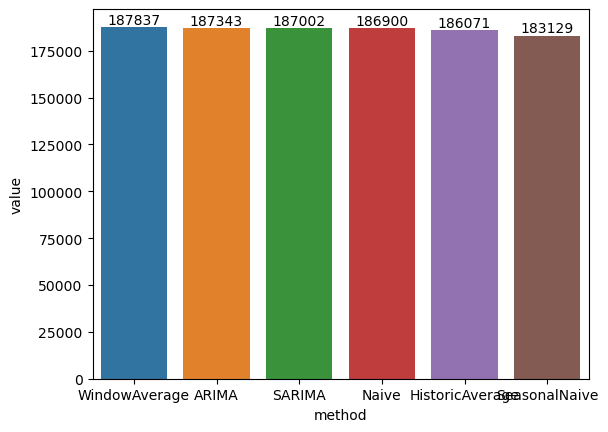

In [29]:
ax=sns.barplot(x='method', y='value', data=evaluation_df1.sort_values(by='value', ascending=False))
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [30]:
small_df = df1[df1["unique_id"].isin(unique_ids)]

models = [
    SeasonalNaive(season_length=7),
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="D")
cv_df = sf.cross_validation(
    h=horizon, # 7 days
    df=small_df,
    n_windows=8,
    step_size=horizon,
    refit=True
)

cv_df.head()

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA,SARIMA
0,house,2019-07-17,2019-07-17,536000.0,829000.0,641490.5625,598495.1250
1,house,2019-07-17,2019-07-17,485000.0,670000.0,667907.3750,623936.6875
2,house,2019-07-17,2019-07-17,585000.0,610000.0,695374.8750,631794.6875
3,house,2019-07-18,2019-07-17,585000.0,600000.0,708611.0000,634734.0000
4,house,2019-07-18,2019-07-17,615000.0,705000.0,710307.1875,620978.8125


In [31]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_eval = cv_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_eval

,metric,SeasonalNaive,ARIMA,SARIMA
0,mae,187428.578125,125577.625,126490.140625


In [32]:
cv_eval = pd.melt(
    cv_eval,
    id_vars=['metric'],
    var_name='method',
    value_name='value'
)
print(cv_eval)

  metric         method          value
0    mae  SeasonalNaive  187428.578125
1    mae          ARIMA  125577.625000
2    mae         SARIMA  126490.140625


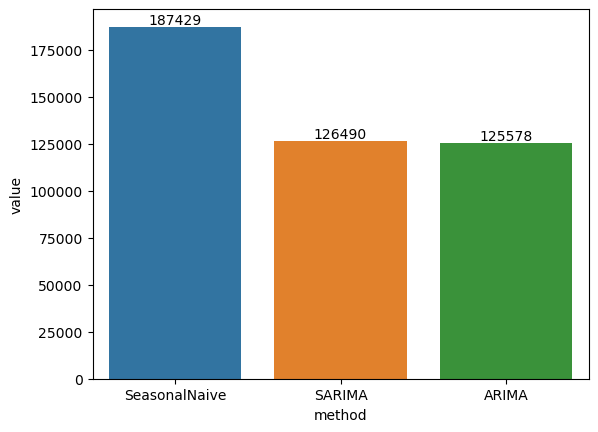

In [33]:
ax=sns.barplot(x='method', y='value', data=cv_eval.sort_values(by='value', ascending=False))
for container in ax.containers:
    ax.bar_label(container)
plt.show()